# 日文新闻主题聚类

使用字符 TF-IDF、TruncatedSVD 和 MiniBatchKMeans 对 Livedoor 新闻进行无监督聚类。编辑栏目标签只用于聚类完成后的外部评价。

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from news_clustering import *
sns.set_theme(style="whitegrid")

## 1. 数据概览

In [2]:
data = load_articles(ensure_data(PROJECT_ROOT / "data"))
pd.DataFrame(
    {
        "文章数": [len(data)],
        "编辑栏目数": [data.category.nunique()],
        "标题平均长度": [data.title.str.len().mean()],
    }
).round(1)

,文章数,编辑栏目数,标题平均长度
0,7367,9,37.7


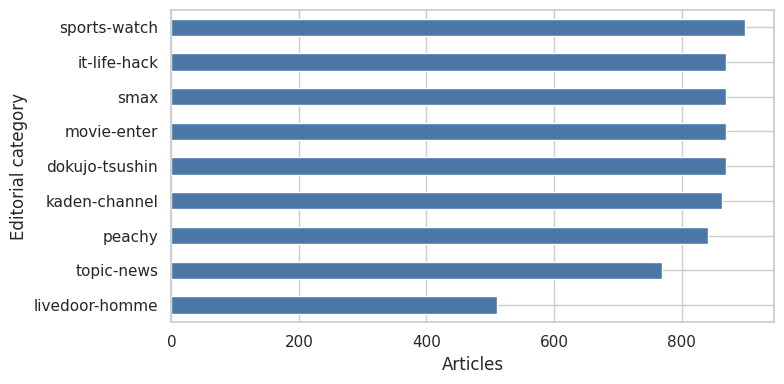

In [3]:
data.groupby("category").size().sort_values().plot.barh(figsize=(8, 4), color="#4c78a8")
plt.xlabel("Articles")
plt.ylabel("Editorial category")
plt.tight_layout()
plt.show()

## 2. 文本表示与无监督选簇

In [4]:
representation = Pipeline(
    [
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), min_df=3, max_df=.95, sublinear_tf=True, max_features=80000)),
        ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
        ("normalize", Normalizer(copy=False)),
    ]
)
documents = data.title + " " + data.content.str.slice(0, 1000)
embedding = representation.fit_transform(documents)
k_table = select_k(embedding, list(range(6, 21)))
k_table.round(3)

,k,silhouette_mean,silhouette_std,stability_ari,selection_score
0,6,0.139,0.023,0.464,0.065
1,7,0.149,0.014,0.527,0.079
2,8,0.158,0.003,0.611,0.097
3,9,0.162,0.005,0.633,0.102
4,10,0.153,0.004,0.601,0.092
5,11,0.153,0.007,0.601,0.092
6,12,0.154,0.017,0.575,0.088
7,13,0.160,0.005,0.550,0.088
8,14,0.166,0.008,0.541,0.090
9,15,0.161,0.006,0.560,0.090


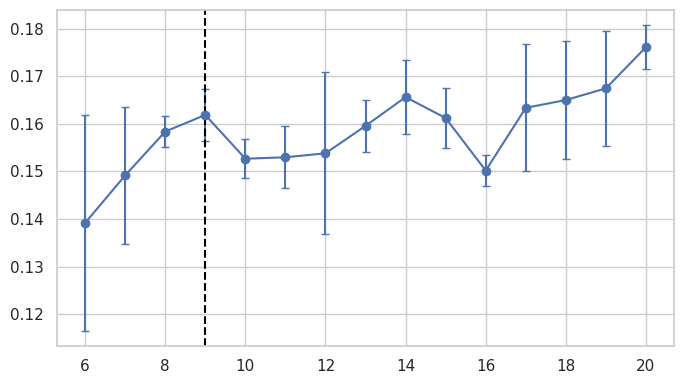

In [5]:
best_row = k_table.sort_values(["selection_score", "silhouette_mean"], ascending=False).iloc[0]
best_k = int(best_row["k"])
plt.figure(figsize=(7, 4))
plt.errorbar(k_table["k"], k_table["silhouette_mean"], yerr=k_table["silhouette_std"], marker="o", capsize=3)
plt.axvline(best_k, color="black", linestyle="--")
plt.tight_layout()
plt.show()

## 3. 最终聚类与代表标题

In [6]:
model = MiniBatchKMeans(n_clusters=best_k, n_init=30, batch_size=512, random_state=SEED).fit(embedding)
metrics = {
    "Silhouette": best_row.silhouette_mean,
    "Stability ARI": best_row.stability_ari,
    "ARI": adjusted_rand_score(data.category, model.labels_),
    "NMI": normalized_mutual_info_score(data.category, model.labels_),
}
pd.DataFrame([metrics]).round(3)

,Silhouette,Stability ARI,ARI,NMI
0,0.162,0.633,0.488,0.647


In [7]:
summary = representative_titles(data, embedding, model)
summary

,cluster,size,representative_titles
4,4,1771,歯に描かれた電子タトゥーが、 虫歯や感染症を予防する【サイエンスニュース】 | 進む資料のデ...
1,1,1602,コンプレックスを自信に変える女たち | 秋の夜長に……独女がオススメしたい「心の一冊」 | ...
0,0,895,志村けん、全米で大ヒット中の映画で声優に初挑戦 | 謎の人体発火、ウルフドッグによる連続殺人...
7,7,789,わずか7.8mmのボディに全部入り！スタイリッシュスマートフォン「MEDIAS X N-07...
2,2,687,SMAP木村拓哉のスピード違反に「反省してるのか?」 | 女性教授が男子生徒に「なめるな」「...
5,5,590,【Sports Watch】石井慧、女子大生との電撃婚も新婚の実態は？ | 【Sports ...
8,8,408,今度の貞子はネットを使って呪いを拡散？ 「リング」シリーズ最新作の構想が明らかに【話題】 |...
3,3,341,「僕らの年代では一番うまい」 中田英が絶賛する日本人選手の現在とは・・・ | サッカー米国女...
6,6,284,なんとソーラー電源で稼働！デジタルクッキングスケール「ＳＤ−００４」【売れ筋チェック】 | ...


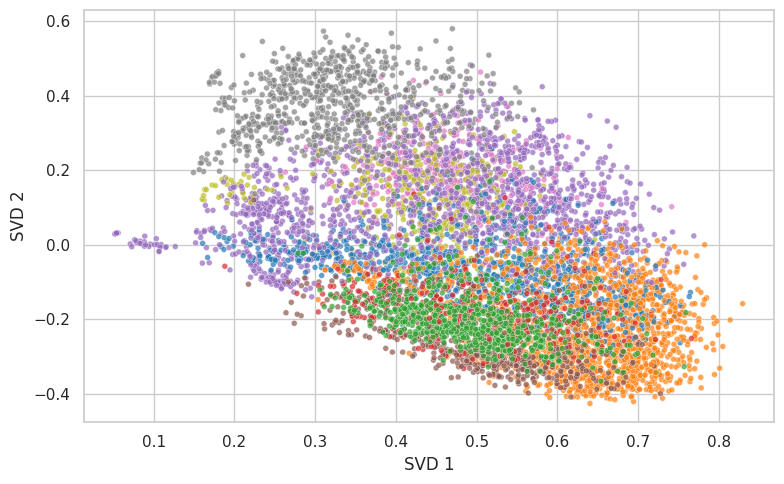

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=model.labels_, palette="tab10", s=18, alpha=.7, legend=False)
plt.xlabel("SVD 1")
plt.ylabel("SVD 2")
plt.tight_layout()
plt.show()

## 结论

- 簇数在 `k=6...20` 中选择，并通过三个随机种子的平均轮廓系数与稳定性共同检查。
- 编辑栏目只用于最终外部评价，不参与簇数选择。
- 代表标题表明，模型识别出了体育、电影、Android、科技和女性生活等主题。
- 二维投影只用于展示；聚类实际在归一化后的 100 维空间中完成。